In [100]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import RBFInterpolator
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy import stats

sys.path.append('C:\\Users\\evils\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData

# Исходные данные

In [24]:
ed = ExperimentData()
experiment_variations = ed.get_all_available_variations()
experiment_variations_with_CO = []

for experiment_variation in experiment_variations:
    if 'CO' in experiment_variation:
        experiment_variations_with_CO.append(experiment_variation)

experiment_data = {}

for experiment_variation in experiment_variations_with_CO:
    ed.get_experiment_data(*experiment_variation)
    experiment_data[*experiment_variation] = ed.df

experiment_data[('diesel', 'steam', 'CO')]

,F_fuel,F_steam,CO
0,0.50,0.2,500.00
1,0.60,0.2,26.40
2,0.60,0.4,500.00
3,0.65,0.4,500.00
4,0.70,0.2,14.90
5,0.70,0.4,32.05
6,0.70,0.6,500.00
7,0.75,0.6,500.00
8,0.80,0.2,8.55
9,0.80,0.4,49.30


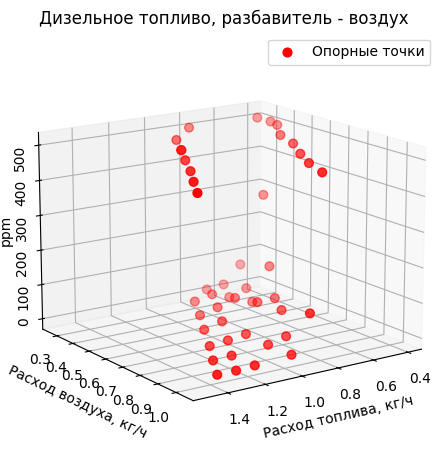

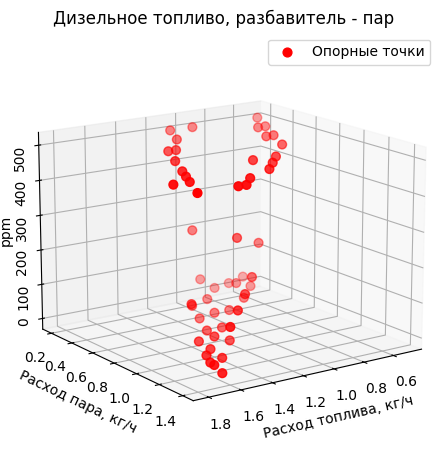

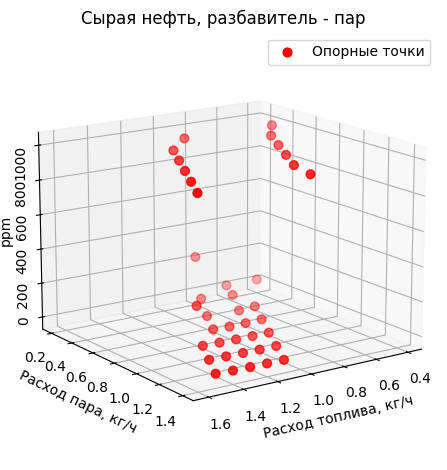

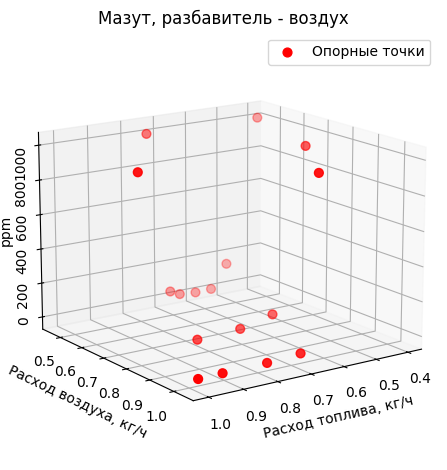

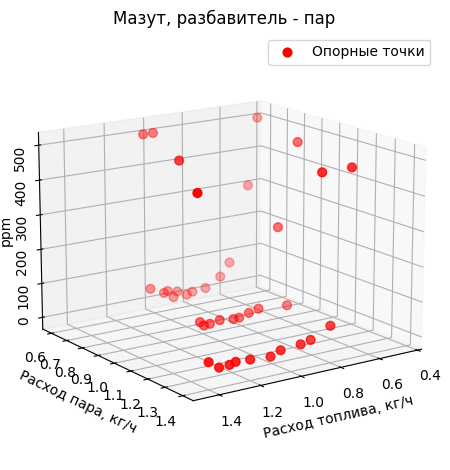

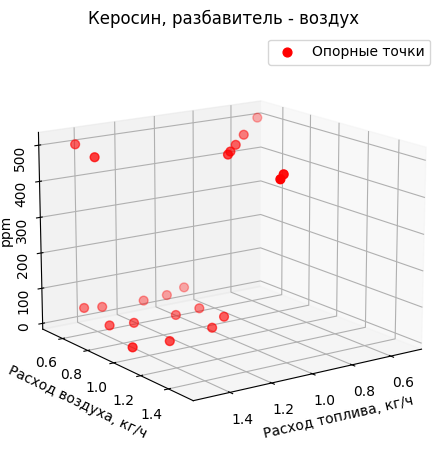

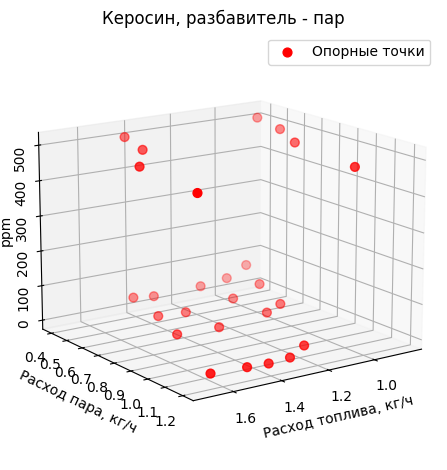

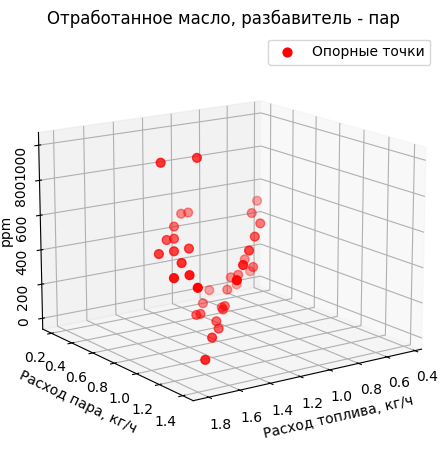

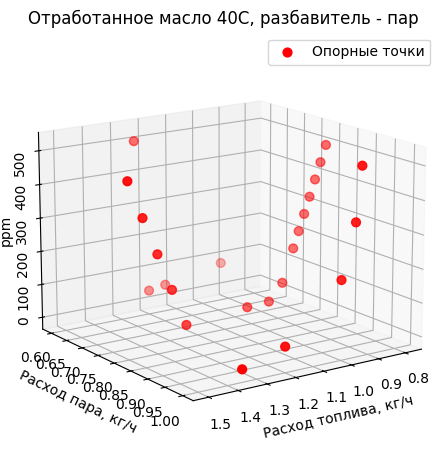

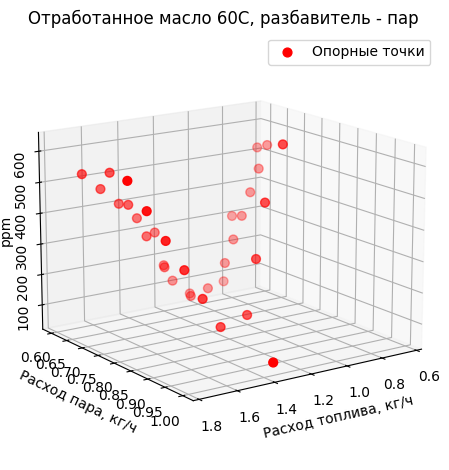

In [97]:
def title_on_russian(title: str) -> str:
    titles_on_russian = {
        'diesel': 'Дизельное топливо',
        'crude_oil': 'Сырая нефть',
        'heavy_oil': 'Мазут',
        'kerosene': 'Керосин',
        'waste_oil': 'Отработанное масло',
        'waste_oil_40_2024': 'Отработанное масло 40С',
        'waste_oil_60_2024': 'Отработанное масло 60С',

        'air': 'воздух',
        'steam': 'пар'
    }
    return titles_on_russian[title]

for experiment_name in experiment_data:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    if 'air' in experiment_name:
        y = experiment_data[experiment_name].F_air
        ax.set_ylabel('Расход воздуха, кг/ч')
    else:
        y = experiment_data[experiment_name].F_steam
        ax.set_ylabel('Расход пара, кг/ч')
    
    x = experiment_data[experiment_name].F_fuel
    z = experiment_data[experiment_name].CO

    ax.scatter(x, y, z, c='red', marker='o', s=40, label='Опорные точки')

    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_zlabel('ppm', rotation=90, labelpad=-6)
    ax.set_title(
        f'{title_on_russian(experiment_name[0])}, разбавитель - {title_on_russian(experiment_name[1])}'
    )
    plt.legend()

    # Поворот графика
    ax.view_init(elev=15, azim=55)  # elev - угол возвышения, azim - азимут
    ax.tick_params(axis='z', which='major', pad=0, rotation=90)
    
    plt.tight_layout()
    plt.show()

# RBF

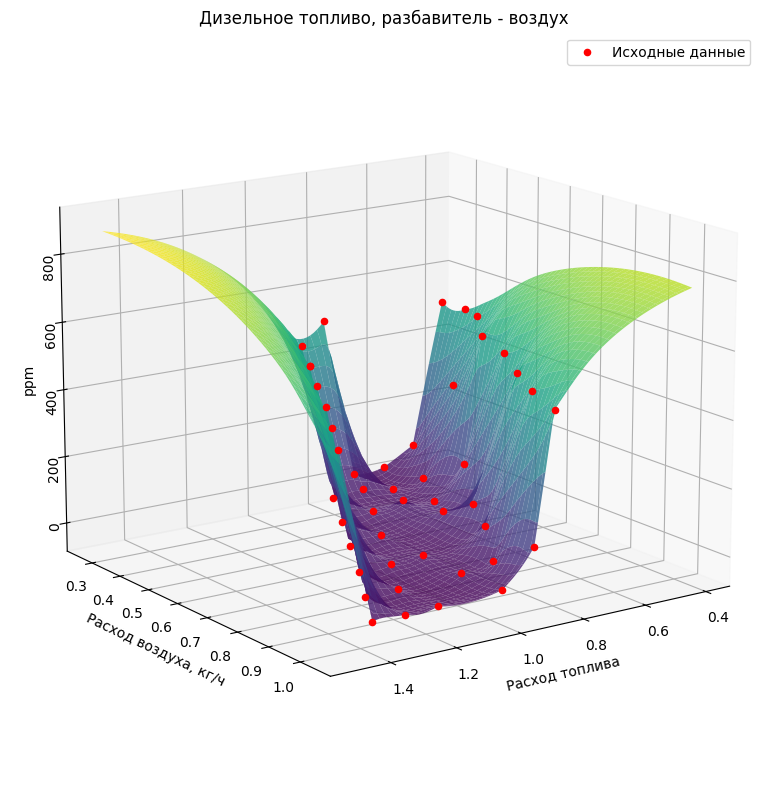

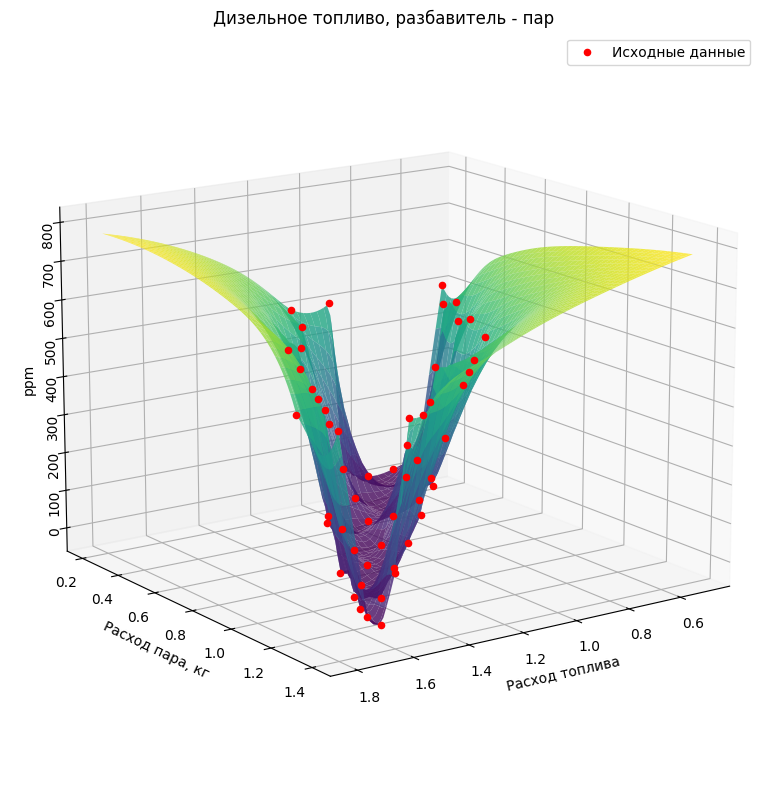

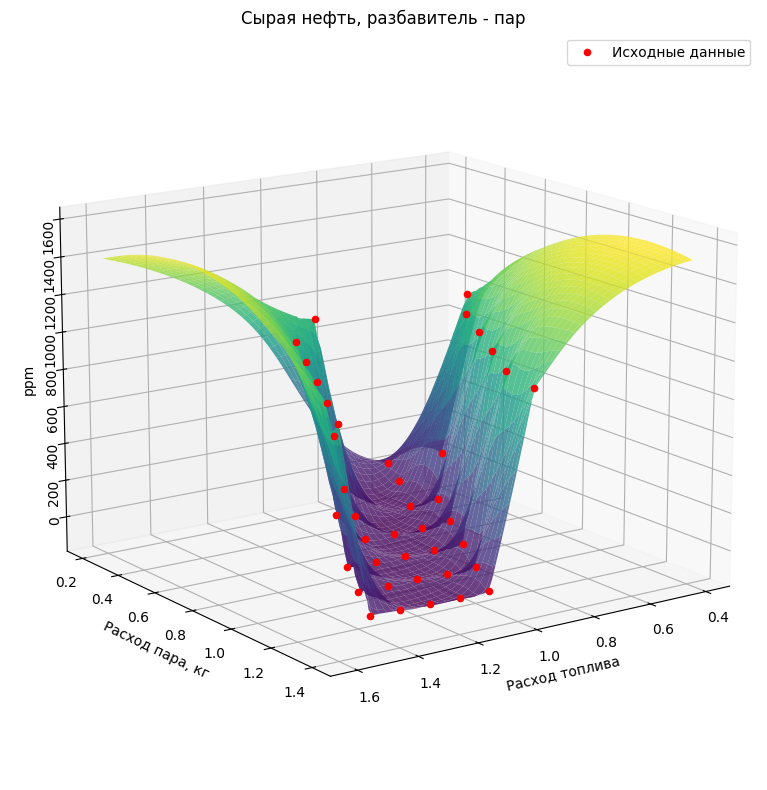

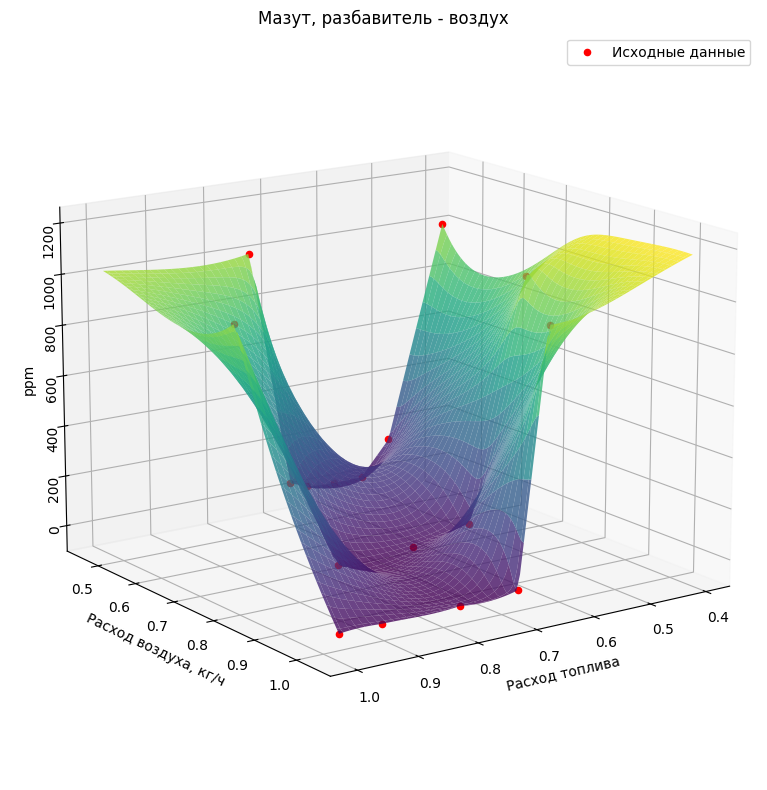

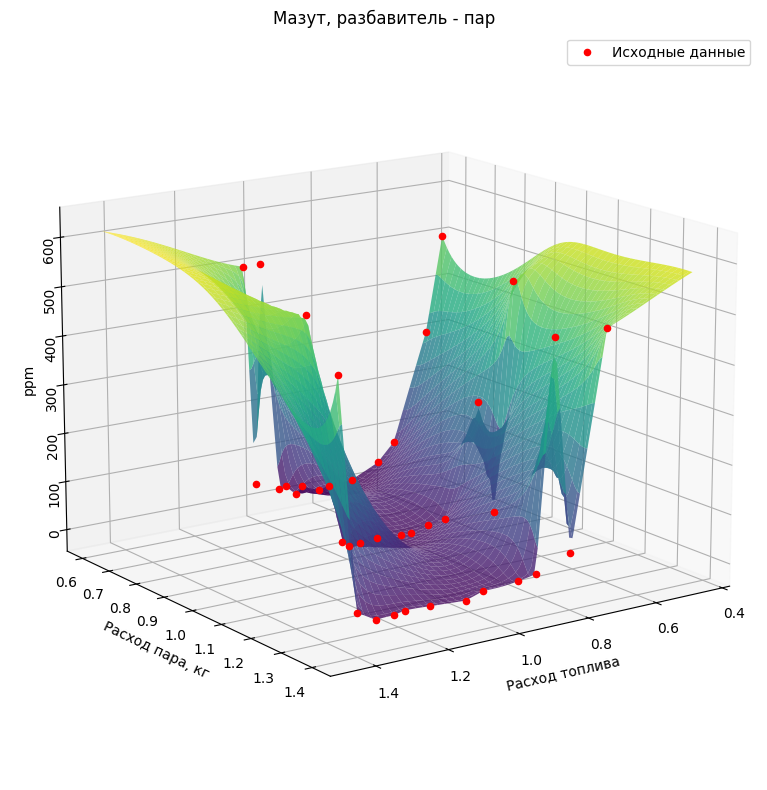

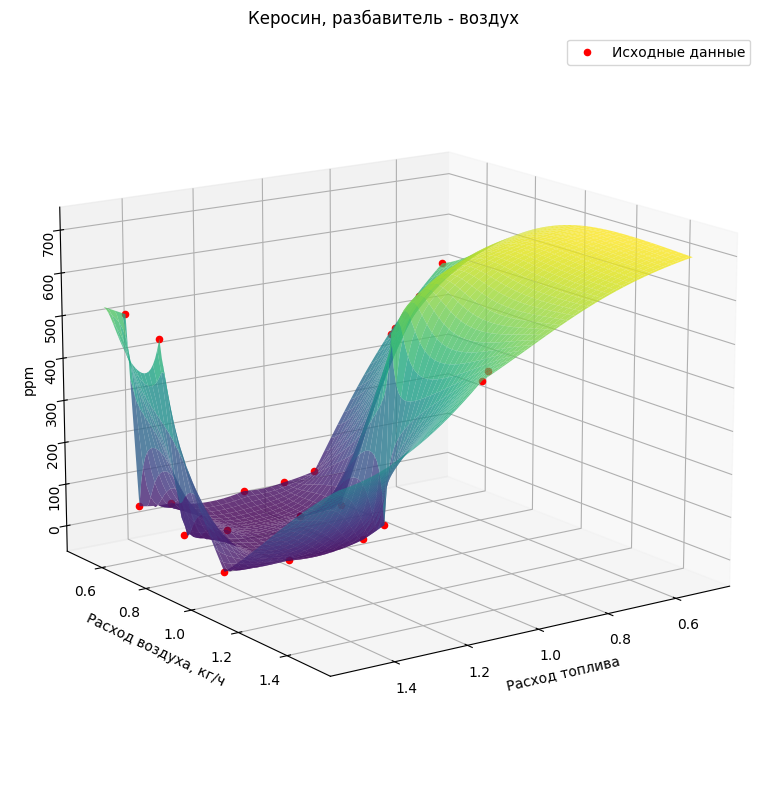

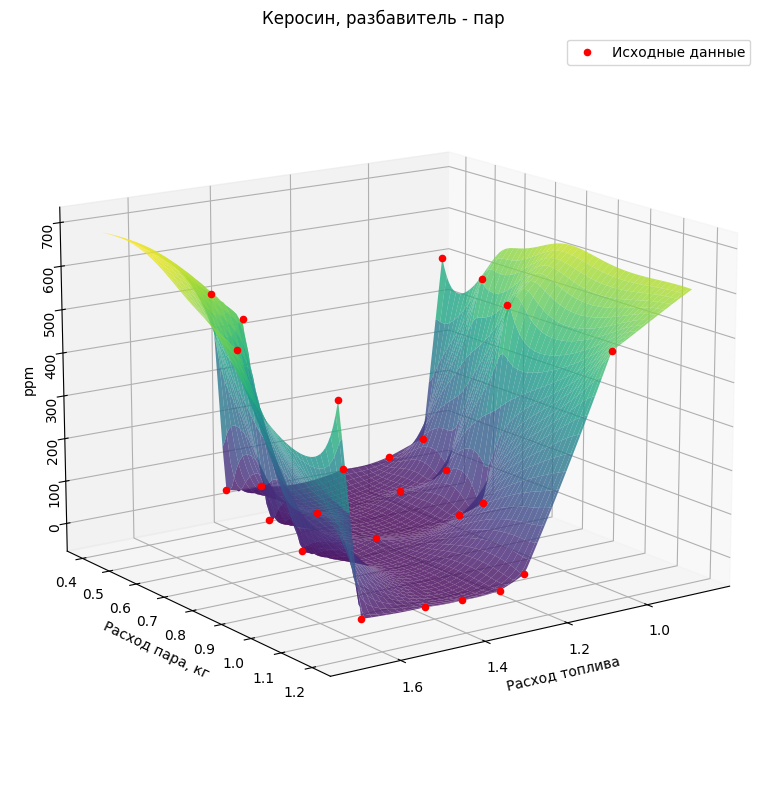

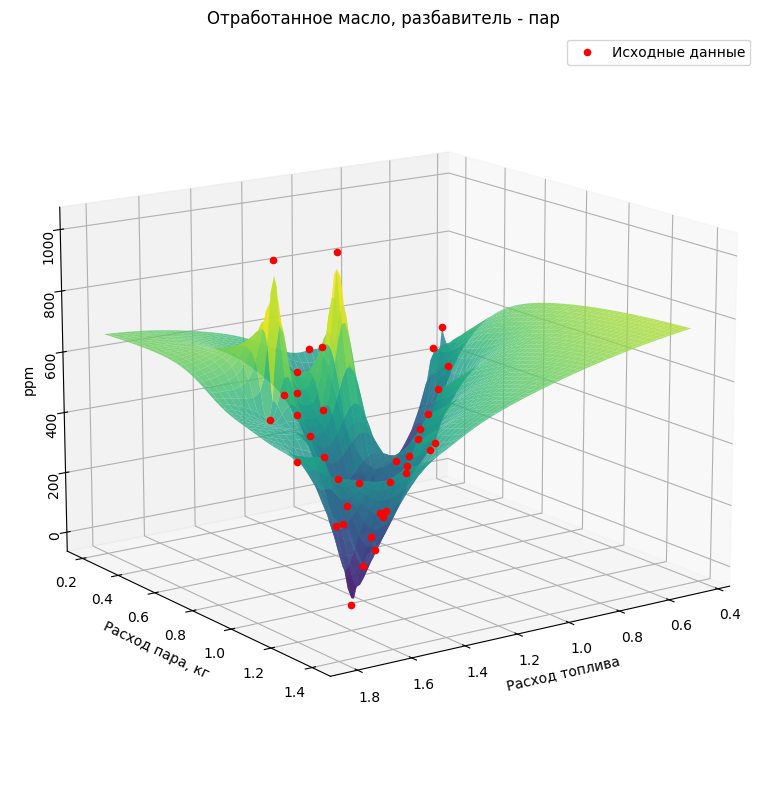

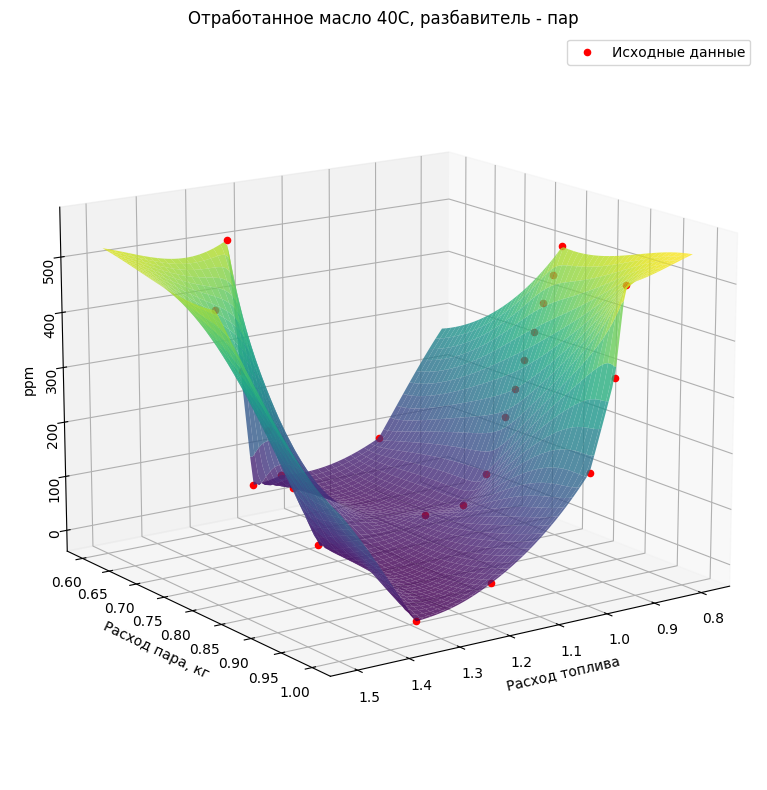

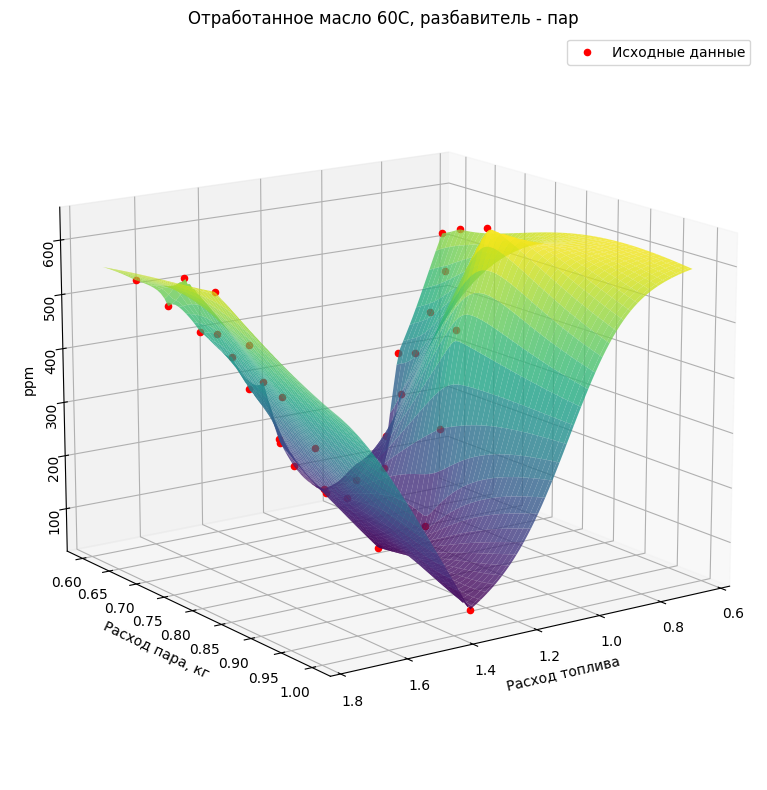

In [148]:
rbf_data = {}

for experiment_name, data in experiment_data.items():
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    if 'air' in experiment_name:
        y = np.array(data.F_air)
        y_min, y_max = data.F_air.min(), data.F_air.max()
        f_additive =  data.F_air
        ax.set_ylabel("Расход воздуха, кг/ч")
    else:
        y = np.array(data.F_steam)
        y_min, y_max = data.F_steam.min(), data.F_steam.max()
        f_additive =  data.F_steam
        ax.set_ylabel("Расход пара, кг")
    
    y = y.reshape(-1, 1)
    x = np.array(data.F_fuel).reshape(-1, 1)
    x_min, x_max = data.F_fuel.min(), data.F_fuel.max()
    
    xy = np.concatenate((x, y), axis=1)
    
    z = np.array(data.CO)
    
    rbfi = RBFInterpolator(xy, z, kernel='linear')
        
    # Создаем плотную сетку
    x_grid = np.linspace(x_min, x_max, 100)
    y_grid = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # Преобразуем сетку в формат (n_samples, 2)
    xy_grid = np.column_stack((X.ravel(), Y.ravel()))

    Z = rbfi(xy_grid)

    Z = Z.reshape(X.shape)

    rbf_data[experiment_name] = X, Y, Z

    """ПОСТРОЕНИЕ ГРАФИКА"""
    # Поверхность интерполяции
    surf = ax.plot_surface(
        X, Y, Z,
        cmap="viridis",      # Цветовая карта
        alpha=0.8,           # Прозрачность
        antialiased=True     # Сглаживание
    )
    # Исходные точки данных
    ax.scatter(
        data.F_fuel, f_additive, data.CO,
        c="red", 
        s=20, 
        label="Исходные данные",
        depthshade=False
    )

    # Настройки графика
    ax.set_xlabel("Расход топлива")
    ax.set_zlabel('ppm', rotation=90, labelpad=-6)
    ax.set_title(
        f'{title_on_russian(experiment_name[0])}, разбавитель - {title_on_russian(experiment_name[1])}'
    )
    plt.legend()
    ax.view_init(elev=15, azim=55)  # elev - угол возвышения, azim - азимут
    ax.tick_params(axis='z', which='major', pad=-3, rotation=90)
    plt.tight_layout()
    plt.show()